# Fussing with the QG outputs

In [1]:
# imports
import os

import xarray
import pandas

import numpy as np
# import fsspec
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from profiler.gliderdata import SprayData
from profiler.profilerpairs import ProfilerPairs
from profiler import io as p_io

# Load up

In [2]:
# Generated by writing the intermediate output from qg_100km.py 
SFtest =  xarray.open_dataset('SFtest.nc')

In [3]:
SFtest

<xarray.Dataset> Size: 3GB
Dimensions:  (dcorr: 1740, x: 26, y: 26, time: 100)
Coordinates:
  * x        (x) float64 208B 4.512e+05 4.551e+05 ... 5.449e+05 5.488e+05
  * y        (y) float64 208B 4.512e+05 4.551e+05 ... 5.449e+05 5.488e+05
  * time     (time) float64 800B 4.321e+08 4.322e+08 ... 4.406e+08 4.406e+08
    lev      int64 8B ...
Dimensions without coordinates: dcorr
Data variables:
    dr       (dcorr, x, y, time) float64 941MB ...
    ulls     (dcorr, x, y, time) float64 941MB ...
    utts     (dcorr, x, y, time) float64 941MB ...

In [4]:
SFtest.x.values[0]

np.float64(451171.875)

In [5]:
SFtest = SFtest.isel(time=0)

In [6]:
np.sum(np.isfinite(SFtest.dr))

<xarray.DataArray 'dr' ()> Size: 8B
array(228150)
Coordinates:
    lev      int64 8B ...
    time     float64 8B 4.321e+08

## Gliders

In [7]:
# Gliders
gliders_df = pandas.read_csv('QG/data/stationary_gliders_ts5001_nd100_df.csv')
gliders_df.head()

,x,y,time,missid,x_m,y_m,u_qg,v_qg
0,115.0,115.0,432086400.0,0,451171.875,451171.875,-0.031685,0.020684
1,116.0,115.0,432086400.0,1,455078.125,451171.875,-0.032276,0.050447
2,117.0,115.0,432086400.0,2,458984.375,451171.875,-0.033166,0.070154
3,118.0,115.0,432086400.0,3,462890.625,451171.875,-0.035052,0.057872
4,119.0,115.0,432086400.0,4,466796.875,451171.875,-0.036180,0.032670


## Cut down to the first time stamp

In [8]:
gliders_df = gliders_df[gliders_df.time == 432086400.0]
len(gliders_df)

676

# Profiler

In [24]:
meta = {}
# Build SprayData objects — one per glider
gliders = SprayData.all_from_QG_glider(gliders_df, meta)

# Construct ProfilerPairs
pairs = ProfilerPairs(
    gliders,
    max_time=1.,
    avoid_same_glider=True,
    randomize=False,
)
pairs.calc_delta(iz=0, variables='duLduLduL')

Using lonendpts: (np.float64(4.499640028797696), np.float64(4.499640028797696))
Using latendpts: (np.float64(4.499540028797696), np.float64(4.499740028797696))


In [10]:
len(gliders)

676

In [11]:
pairs.r.min()

np.float64(3.894210260340035)

# dr histograms

In [14]:
pairs.r.max()

np.float64(137.89412291282977)

In [15]:
good_dr = np.isfinite(SFtest.dr.values)
SFtest.dr.values[good_dr].flatten().min()/1e3

np.float64(3.90625)

In [16]:
np.sum(good_dr)

np.int64(228150)

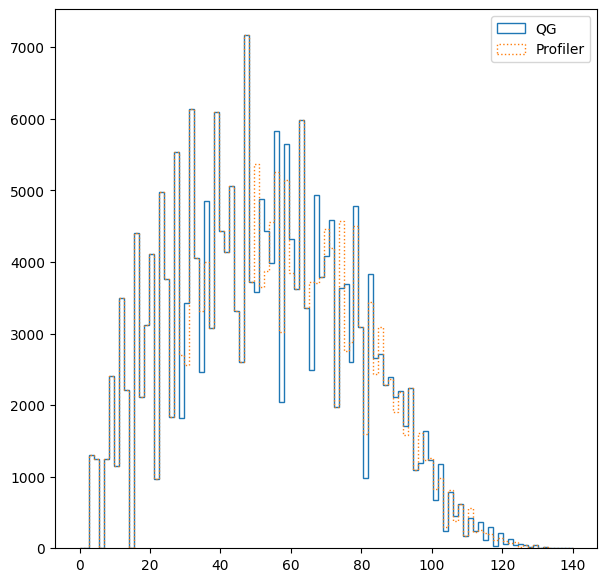

In [17]:
rbins = np.linspace(0., 140., 100)

fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.hist(SFtest.dr.values.flatten()/1e3, bins=rbins, label='QG', histtype='step')
ax.hist(pairs.r, bins=rbins, label='Profiler', histtype='step', linestyle='dotted')

ax.legend()
plt.show()

# Hopefully good enough..

----

# Velocities

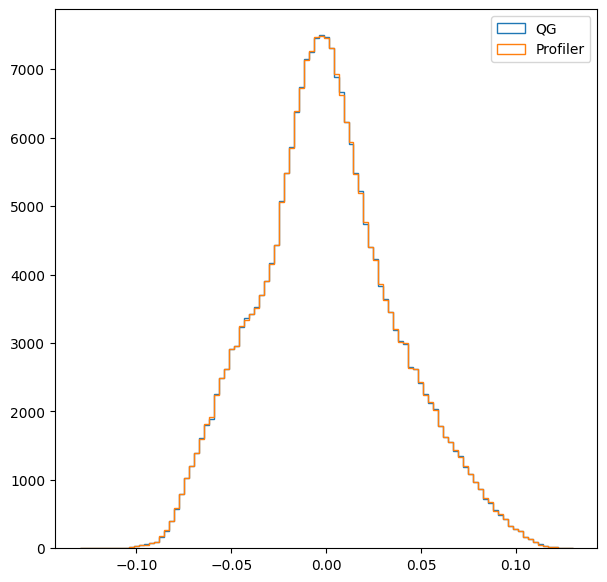

In [26]:
ubins = np.linspace(-0.13, 0.13, 100)
#ubins = None

fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.hist(SFtest.ulls.values.flatten(), bins=ubins, label='QG', histtype='step')
ax.hist(pairs.duL, bins=ubins, label='Profiler', histtype='step')#, linestyle='dotted')

ax.legend()
plt.show()